# TinyML-Based Intelligent Water Quality Monitoring Node
### SDG 6 – Clean Water and Sanitation

Author: Aditya Kumar
Project: IBM GenAI Internship Bootcamp  
Objective: Detect unsafe water conditions using a lightweight ML model and trigger automated alerts.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn sentence-transformers


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from sentence_transformers import SentenceTransformer

In [ ]:
import pandas as pd



data = pd.read_csv('/content/drive/MyDrive/project /dataset/data.csv')


data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
data.shape

(3276, 10)

In [ ]:
data.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [ ]:
data.fillna(data.mean(), inplace=True)

In [ ]:
data.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [ ]:
X = data.drop("Potability", axis=1)
y = data["Potability"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=50)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.676829268292683


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.70      0.86      0.77       412
           1       0.61      0.36      0.46       244

    accuracy                           0.68       656
   macro avg       0.65      0.61      0.61       656
weighted avg       0.66      0.68      0.65       656



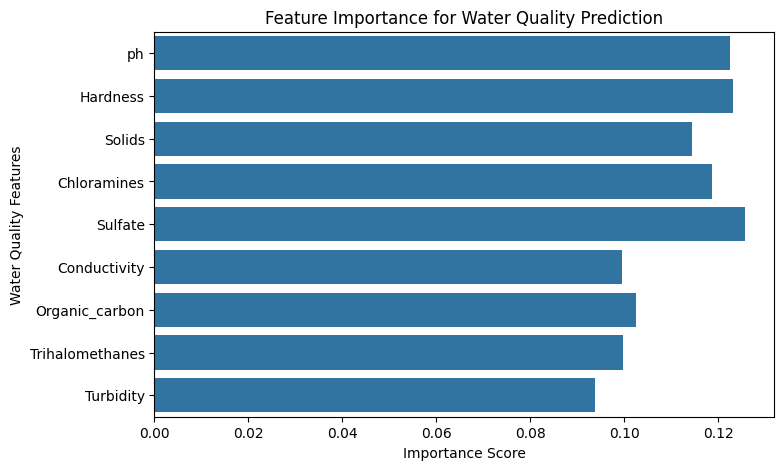

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feature_names)

plt.title("Feature Importance for Water Quality Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Water Quality Features")

plt.show()

In [ ]:
def water_quality_alert(prediction):

    if prediction == 1:
        return " tested water is Safe for Drinking"

    else:
        return " ALERT: tested water is not safe for drinking.Contamination Detected!"

In [ ]:
sample = X_test.iloc[0]

prediction = model.predict([sample])[0]

print(water_quality_alert(prediction))

 ALERT: tested water is not safe for drinking.Contamination Detected!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
def trigger_alert():

    print("ALERT TRIGGERED")
    print("Unsafe water detected!")
    print("Notification sent to monitoring authority")

In [ ]:
if prediction == 0:
    trigger_alert()

ALERT TRIGGERED
Unsafe water detected!
Notification sent to monitoring authority
